<a href="https://colab.research.google.com/github/ATSASSE/Projet_DataScience/blob/Hilan/Projets_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
from google.colab import files
uploaded = files.upload()  # Permet de téléverser un fichier

# Charger le fichier CSV
import io
data = pd.read_csv(io.BytesIO(uploaded['Tetuan-PC.csv']))
print(data.head())


Saving Tetuan-PC.csv to Tetuan-PC.csv
             DateTime  Temperature  Humidity  WindSpeed  GenDiffFlows  \
24625  6/21/2017 0:00        21.86      77.0      0.081         0.073   
24626  6/21/2017 0:10        21.91      76.0      0.077         0.077   
24627  6/21/2017 0:20        21.96      75.5      0.081         0.055   
24628  6/21/2017 0:30        21.83      75.1      0.078         0.062   
24629  6/21/2017 0:40        21.60      75.8      0.075         0.048   

       DiffFlows      PCZone1      PCZone2      PCZone3  
24625      0.111  44554.17219  24750.93555  26980.43077  
24626      0.096  44249.00662  24612.47401  26631.87692  
24627      0.096  43753.11258  24339.29314  26141.53846  
24628      0.163  43079.20530  24208.31601  26052.92308  
24629      0.145  42634.17219  23927.65073  25887.50769  


1. nombre d'observations (lignes) et de variables (colonnes).

In [4]:

print(f"Nombre d'observations: {data.shape[0]}, Nombre de variables: {data.shape[1]}")

Nombre d'observations: 13248, Nombre de variables: 9


Y'a t'ils des valeurs manquantes dans la dataset?

Non nous avons pas
Donc pas besoin de supprimez les varaiables concernées

In [5]:
print("\nValeurs manquantes par colonne :")
print(data.isnull().sum())


Valeurs manquantes par colonne :
DateTime        0
Temperature     0
Humidity        0
WindSpeed       0
GenDiffFlows    0
DiffFlows       0
PCZone1         0
PCZone2         0
PCZone3         0
dtype: int64


Statistiques descriptives :

In [6]:
print("\nStatistiques descriptives :")
print(data.describe())


Statistiques descriptives :
        Temperature      Humidity     WindSpeed  GenDiffFlows     DiffFlows  \
count  13248.000000  13248.000000  13248.000000  13248.000000  13248.000000   
mean      25.353431     63.239117      4.000284    254.436238     68.161448   
std        3.687087     18.150509      1.857605    310.646997     91.721217   
min       13.990000     11.340000      0.050000      0.018000      0.019000   
25%       22.750000     50.260000      4.904000      0.088000      0.122000   
50%       25.140000     65.050000      4.910000     61.540000     35.030000   
75%       27.430000     78.300000      4.919000    526.100000    100.200000   
max       40.010000     93.800000      4.998000    978.000000    558.700000   

            PCZone1       PCZone2       PCZone3  
count  13248.000000  13248.000000  13248.000000  
mean   35272.400777  22976.430993  23544.040816  
std     7073.784592   5239.586748   7667.598488  
min    18283.684790  10624.116420   8189.908069  
25%    29

2.3 PRINCIPAL COMPONENT ANALYSYS (PCA)

1. calculons la variance

In [9]:
# Calcul de la variance pour chaque variable
variance = data[['Temperature', 'Humidity', 'WindSpeed', 'PCZone1', 'PCZone2', 'PCZone3']].var()
print("Variance de chaque variable :\n", variance)


Variance de chaque variable :
 Temperature    1.359461e+01
Humidity       3.294410e+02
WindSpeed      3.450695e+00
PCZone1        5.003843e+07
PCZone2        2.745327e+07
PCZone3        5.879207e+07
dtype: float64


standardiser les données

In [13]:
# Standardisation des données
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data[['Temperature', 'Humidity', 'WindSpeed', 'PCZone1', 'PCZone2', 'PCZone3']])
print("Données standardisées :\n", data_scaled)

Données standardisées :
 [[-0.9475132   0.75818274 -2.10993862  1.31218609  0.3386854   0.44818722]
 [-0.93395185  0.70308579 -2.11209201  1.26904411  0.31225836  0.40272748]
 [-0.92039049  0.67553731 -2.10993862  1.19893839  0.26011853  0.33877565]
 ...
 [-0.29928049 -0.40491395  0.49405068 -0.29798456 -0.64482901 -1.0855549 ]
 [-0.34267682 -0.37405966  0.49566572 -0.37274928 -0.74268047 -1.12085327]
 [-0.36166272 -0.36469318  0.49728076 -0.50246156 -0.80339124 -1.19298472]]


2.Perform PCA

In [14]:
# Initialisation de la PCA
pca = PCA()

# Ajustement sur les données standardisées
pca.fit(data_scaled)

# Résultats des composantes principales
principal_components = pca.components_
explained_variance = pca.explained_variance_ratio_

print("Composantes principales (vecteurs de charge) :\n", principal_components)
print("\nVariance expliquée par chaque composante principale :\n", explained_variance)

Composantes principales (vecteurs de charge) :
 [[ 4.14923060e-01 -2.90470949e-01  1.39773620e-01  4.78141095e-01
   5.10305554e-01  4.84662925e-01]
 [-3.89919443e-01  7.07420051e-01  4.61584723e-01  1.85672781e-01
   1.60632838e-01  2.72363639e-01]
 [ 2.53024524e-01 -2.52894599e-01  8.30290088e-01 -3.51798550e-01
  -2.42595704e-01 -5.13679879e-03]
 [ 7.68088990e-01  5.91074521e-01 -1.38729597e-01 -1.93065720e-01
  -8.54004974e-03 -6.38514473e-02]
 [-7.65622974e-02 -2.50371685e-02 -2.42434907e-01 -4.67188347e-01
  -2.23291258e-01  8.16463553e-01]
 [-1.26324146e-01 -3.50980205e-02  8.14505024e-04 -5.98000976e-01
   7.77817934e-01 -1.42139964e-01]]

Variance expliquée par chaque composante principale :
 [0.55489045 0.17926885 0.16618705 0.05573653 0.03388953 0.01002758]


3. PVE

Pourcentage de variance expliqué PVE

In [17]:
# Variance expliquée (PVE) et variance cumulée
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Affichage des résultats
print("PVE par composante principale :")
for i, ev in enumerate(explained_variance, 1):
    print(f"Composante {i}: {ev*100:.2f}%")
print("\nVariance expliquée cumulée :")
print(cumulative_variance)


PVE par composante principale :
Composante 1: 55.49%
Composante 2: 17.93%
Composante 3: 16.62%
Composante 4: 5.57%
Composante 5: 3.39%
Composante 6: 1.00%

Variance expliquée cumulée :
[0.55489045 0.7341593  0.90034635 0.95608288 0.98997242 1.        ]


tracez


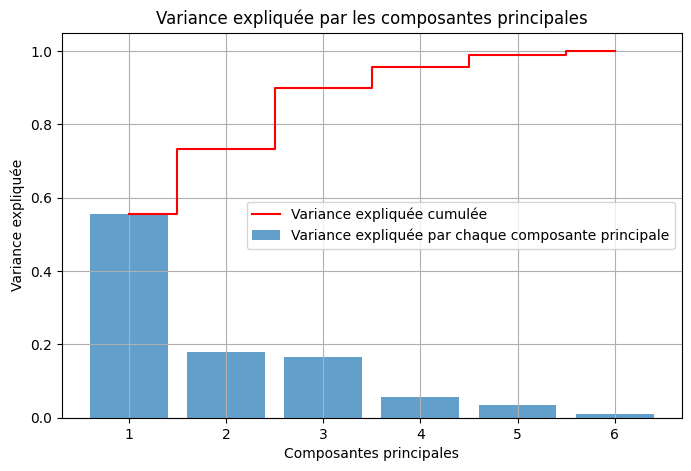

In [18]:


# Variance expliquée cumulée
cumulative_variance = np.cumsum(explained_variance)

# Tracé
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, align='center',
        label='Variance expliquée par chaque composante principale')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid',
         label='Variance expliquée cumulée', color='red')
plt.xlabel('Composantes principales')
plt.ylabel('Variance expliquée')
plt.title('Variance expliquée par les composantes principales')
plt.legend(loc='best')
plt.grid()
plt.show()


4.  correlation circle

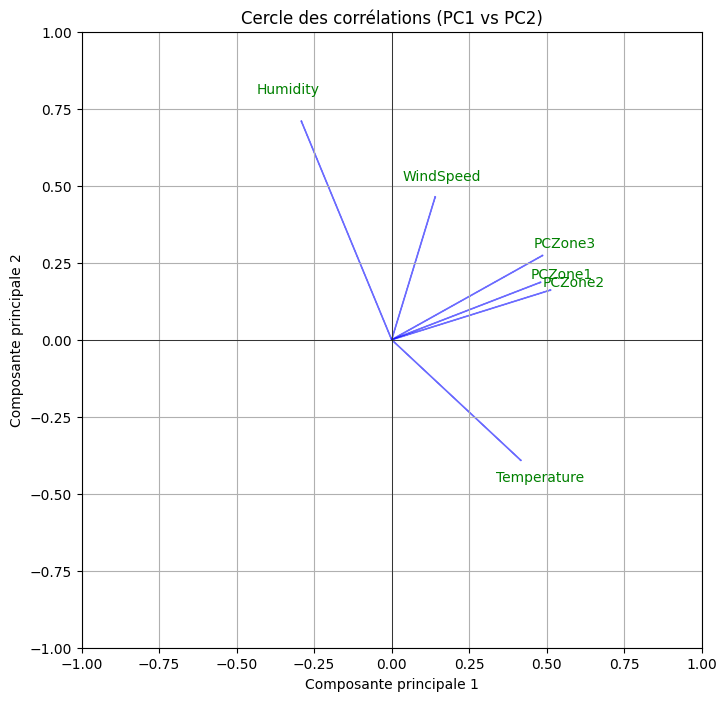

In [16]:
# Cercle des corrélations
plt.figure(figsize=(8, 8))

for i in range(len(variables)):
    plt.arrow(0, 0, principal_components[0, i], principal_components[1, i], color='b', alpha=0.5)
    plt.text(principal_components[0, i] * 1.15, principal_components[1, i] * 1.15, variables[i],
             color='g', ha='center', va='center')

plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.xlabel('Composante principale 1')
plt.ylabel('Composante principale 2')
plt.title('Cercle des corrélations (PC1 vs PC2)')
plt.grid()
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.show()
